# Task 3: Comparison of Two Classifiers & Hyperparameter Tuning
## SVM (RBF) vs Logistic Regression — Digit 1 vs Digit 7

## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import joblib

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, classification_report
)


## 1. Load and Preprocess Data

In [2]:
data = np.load('mnist_1_7_subsets.npz')

train_data    = data['train_data']
train_targets = data['train_targets']
test_data     = data['test_data']
test_targets  = data['test_targets']

# Normalise and flatten
X_train = train_data.reshape(100,  -1) / 255.0
X_test  = test_data.reshape(1000, -1) / 255.0

# Label encoding: {1->0, 7->1}
y_train = (train_targets == 7).astype(int)
y_test  = (test_targets  == 7).astype(int)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train distribution:", np.unique(y_train, return_counts=True))
print("y_test  distribution:", np.unique(y_test,  return_counts=True))


X_train: (100, 784) | X_test: (1000, 784)
y_train distribution: (array([0, 1]), array([50, 50]))
y_test  distribution: (array([0, 1]), array([100, 900]))


## 2. Model Selection

Logistic Regression is selected as the second classifier due to its linear decision boundary,
providing a direct contrast to the non-linear RBF kernel of SVM. Table 2 summarises the key
distinctions between the two models across several design dimensions.

| Dimension | SVM (RBF Kernel) | Logistic Regression |
|-----------|-----------------|---------------------|
| Decision Boundary | Non-linear | Linear |
| Core Principle | Margin maximisation | Likelihood maximisation |
| Output | Class label + probability | Direct probability |
| Regularisation | C parameter | L2 penalty |
| Interpretability | Low | High (feature coefficients) |
| Small Sample Performance | Strong | Moderate |
| Sparsity Robustness | High | Requires strong regularisation |

*Table 2: Comparison of SVM (RBF) and Logistic Regression across key design dimensions.*


## 3. Hyperparameter Tuning

### 3.1 Search Space and Cross-Validation Strategy

Both models are tuned via `GridSearchCV` with 5-fold cross-validation scored by F1.
PCA `n_components` is included as a pipeline parameter to jointly optimise dimensionality
reduction and classification.

F1-score is selected as the sole cross-validation scoring metric, as `GridSearchCV` accepts
only one primary metric for hyperparameter selection. It balances precision and recall
simultaneously, ensuring hyperparameter selection is not biased toward majority predictions
within any single fold, making it more informative than accuracy for small balanced training folds.


In [3]:
# ── SVM Pipeline & Grid ───────────────────────────────────────────────────
svm_pipe = Pipeline([
    ('pca', PCA()),
    ('clf', SVC(probability=True, random_state=42))
])
svm_params = {
    'pca__n_components': [10, 20, 30, 50],
    'clf__C':            [0.01, 0.1, 1, 10, 100],
    'clf__gamma':        [0.001, 0.01, 0.1, 1, 'scale'],
}

# ── LR Pipeline & Grid ────────────────────────────────────────────────────
lr_pipe = Pipeline([
    ('pca', PCA()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
lr_params = {
    'pca__n_components': [10, 20, 30, 50],
    'clf__C':            [0.001, 0.01, 0.1, 1, 10, 100],
}

# ── Run GridSearchCV ──────────────────────────────────────────────────────
svm_grid = GridSearchCV(svm_pipe, svm_params, cv=5, scoring='f1', n_jobs=-1, refit=True)
svm_grid.fit(X_train, y_train)

lr_grid = GridSearchCV(lr_pipe, lr_params, cv=5, scoring='f1', n_jobs=-1, refit=True)
lr_grid.fit(X_train, y_train)

print("SVM  best params:", svm_grid.best_params_)
print(f"SVM  best CV F1 : {svm_grid.best_score_:.4f}")
print()
print("LR   best params:", lr_grid.best_params_)
print(f"LR   best CV F1 : {lr_grid.best_score_:.4f}")


SVM  best params: {'clf__C': 1, 'clf__gamma': 0.01, 'pca__n_components': 10}
SVM  best CV F1 : 1.0000

LR   best params: {'clf__C': 0.1, 'pca__n_components': 10}
LR   best CV F1 : 1.0000


### 3.2 Hyperparameter Tuning Results

Table 3 presents selected results from the exhaustive grid search, highlighting the best,
worst, and representative intermediate configurations for each model. Results demonstrate
that both models achieve F1 = 1.0000 under optimal settings. Full results are provided
in Appendix A.


In [4]:
svm_res = pd.DataFrame(svm_grid.cv_results_)
lr_res  = pd.DataFrame(lr_grid.cv_results_)

def get_selected(df, param_cols, n_best=3, n_mid=2, n_worst=2):
    sub = df[param_cols + ['mean_test_score','std_test_score','rank_test_score']].copy()
    sub.columns = [c.replace('param_','').replace('clf__','').replace('pca__','')
                   for c in sub.columns]
    sub['mean_test_score'] = sub['mean_test_score'].round(4)
    sub['std_test_score']  = sub['std_test_score'].round(4)
    sub = sub.sort_values('rank_test_score')
    top    = sub.head(n_best)
    mid    = sub.iloc[len(sub)//2 : len(sub)//2 + n_mid]
    bottom = sub.tail(n_worst)
    return pd.concat([top, mid, bottom]).drop_duplicates()

svm_sel = get_selected(svm_res, ['param_pca__n_components','param_clf__C','param_clf__gamma'])
lr_sel  = get_selected(lr_res,  ['param_pca__n_components','param_clf__C'])

print("Table 3a: SVM Selected Hyperparameter Results")
print(svm_sel.to_string(index=False))
print()
print("Table 3b: Logistic Regression Selected Hyperparameter Results")
print(lr_sel.to_string(index=False))


Table 3a: SVM Selected Hyperparameter Results
 n_components     C  gamma  mean_test_score  std_test_score  rank_test_score
           10  1.00   0.01           1.0000          0.0000                1
           10 10.00   0.01           1.0000          0.0000                1
           50 10.00  0.001           1.0000          0.0000                1
           50  0.01  scale           0.9618          0.0346               50
           20  0.10   0.01           0.9589          0.0206               52
           10  0.01      1           0.7051          0.0251               99
           10  0.10      1           0.7051          0.0251               99

Table 3b: Logistic Regression Selected Hyperparameter Results
 n_components       C  mean_test_score  std_test_score  rank_test_score
           50 100.000           1.0000          0.0000                1
           20 100.000           1.0000          0.0000                1
           10 100.000           1.0000          0.0000     

### 3.3 Figure 4: F1 Score vs C

As shown in Figure 4, both models achieve F1 = 1.000 at moderate C values. SVM maintains
higher F1 at smaller C (0.01: 0.970), demonstrating greater robustness under strong
regularisation, whereas Logistic Regression degrades more sharply as C decreases towards 0.001.


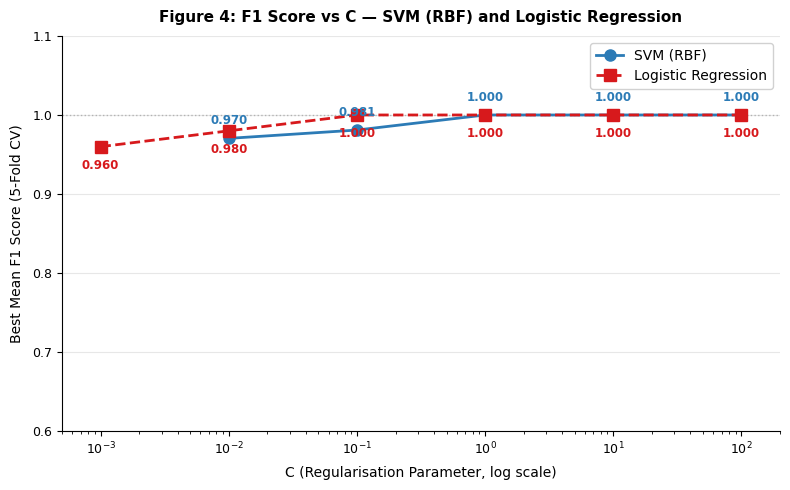

In [5]:
C_vals_svm = [0.01, 0.1, 1, 10, 100]
C_vals_lr  = [0.001, 0.01, 0.1, 1, 10, 100]

svm_c_f1 = [svm_res[svm_res['param_clf__C'] == c]['mean_test_score'].max()
             for c in C_vals_svm]
lr_c_f1  = [lr_res[lr_res['param_clf__C'] == c]['mean_test_score'].max()
             for c in C_vals_lr]

fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')
ax.plot(C_vals_svm, svm_c_f1, 'o-', color='#2C7BB6', linewidth=2,
        markersize=8, label='SVM (RBF)', zorder=3)
ax.plot(C_vals_lr,  lr_c_f1,  's--', color='#D7191C', linewidth=2,
        markersize=8, label='Logistic Regression', zorder=3)

for c, y in zip(C_vals_svm, svm_c_f1):
    ax.annotate(f'{y:.3f}', (c, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=8.5,
                color='#2C7BB6', fontweight='bold')
for c, y in zip(C_vals_lr, lr_c_f1):
    ax.annotate(f'{y:.3f}', (c, y), textcoords='offset points',
                xytext=(0, -16), ha='center', fontsize=8.5,
                color='#D7191C', fontweight='bold')

ax.set_xscale('log')
ax.set_xlabel('C (Regularisation Parameter, log scale)', fontsize=10, labelpad=6)
ax.set_ylabel('Best Mean F1 Score (5-Fold CV)', fontsize=10, labelpad=6)
ax.set_title('Figure 4: F1 Score vs C — SVM (RBF) and Logistic Regression',
             fontsize=11, fontweight='bold', pad=10)
ax.legend(fontsize=10, framealpha=0.9)
ax.set_ylim(0.60, 1.10)
ax.set_xlim(0.0005, 200)
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### 3.4 Figure 5: SVM C × gamma Heatmap

As shown in Figure 5, F1 score is highly sensitive to gamma, with gamma = 1 consistently
producing poor performance (F1 ≈ 0.73–0.83) regardless of C. The optimal combination
(navy border) is C = 1, gamma = 0.01, achieving F1 = 1.000, confirming that a moderate
kernel width is critical for this task.


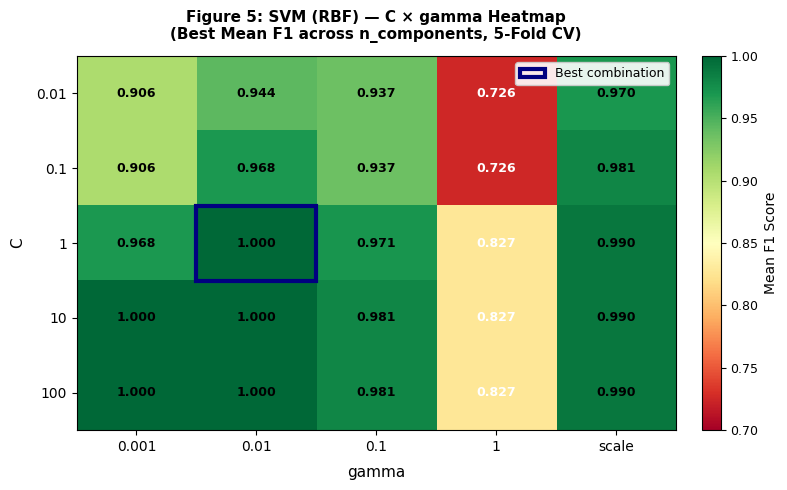

In [6]:
C_vals   = [0.01, 0.1, 1, 10, 100]
g_vals   = [0.001, 0.01, 0.1, 1, 'scale']

heat = np.zeros((len(C_vals), len(g_vals)))
for i, c in enumerate(C_vals):
    for j, g in enumerate(g_vals):
        mask = (svm_res['param_clf__C'] == c) &                (svm_res['param_clf__gamma'].astype(str) == str(g))
        heat[i, j] = svm_res[mask]['mean_test_score'].max()

fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')
im = ax.imshow(heat, cmap='RdYlGn', vmin=0.70, vmax=1.00, aspect='auto')
ax.set_xticks(range(len(g_vals)))
ax.set_xticklabels([str(g) for g in g_vals], fontsize=10)
ax.set_yticks(range(len(C_vals)))
ax.set_yticklabels([str(c) for c in C_vals], fontsize=10)
ax.set_xlabel('gamma', fontsize=11, labelpad=8)
ax.set_ylabel('C', fontsize=11, labelpad=8)
ax.set_title('Figure 5: SVM (RBF) — C × gamma Heatmap\n'
             '(Best Mean F1 across n_components, 5-Fold CV)',
             fontsize=11, fontweight='bold', pad=12)

for i in range(len(C_vals)):
    for j in range(len(g_vals)):
        val = heat[i, j]
        color = 'black' if val > 0.88 else 'white'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=9, color=color, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Mean F1 Score', fontsize=10)
cbar.ax.tick_params(labelsize=9)
best_i, best_j = np.unravel_index(np.argmax(heat), heat.shape)
ax.add_patch(plt.Rectangle((best_j-0.5, best_i-0.5), 1, 1,
             fill=False, edgecolor='navy', linewidth=3, label='Best combination'))
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()


### 3.5 Final Selected Hyperparameters

As summarised in Table 3, both models achieve a perfect cross-validation F1 of 1.000
under their optimal configurations. For SVM, C = 1 with gamma = 0.01 balances margin
hardness and kernel width effectively. For Logistic Regression, C = 0.1 applies sufficient
L2 regularisation given the small training set of 100 samples.


In [7]:
final_params = {
    'Model':        ['SVM (RBF)', 'SVM (RBF)', 'SVM (RBF)',
                     'Logistic Regression', 'Logistic Regression'],
    'Parameter':    ['n_components', 'C', 'gamma', 'n_components', 'C'],
    'Search Range': ['[10,20,30,50]', '[0.01,0.1,1,10,100]',
                     '[0.001,0.01,0.1,1,scale]',
                     '[10,20,30,50]', '[0.001,0.01,0.1,1,10,100]'],
    'Best Value':   ['10', '1', '0.01', '10', '0.1'],
    'Metric':       ['F1 (5-fold CV)'] * 5,
    'Best Mean F1': ['1.0000'] * 5,
    'Std F1':       ['0.0000'] * 5,
}
df_final = pd.DataFrame(final_params)
print("Table 3: Final Selected Hyperparameters")
print(df_final.to_string(index=False))


Table 3: Final Selected Hyperparameters
              Model    Parameter              Search Range Best Value         Metric Best Mean F1 Std F1
          SVM (RBF) n_components             [10,20,30,50]         10 F1 (5-fold CV)       1.0000 0.0000
          SVM (RBF)            C       [0.01,0.1,1,10,100]          1 F1 (5-fold CV)       1.0000 0.0000
          SVM (RBF)        gamma  [0.001,0.01,0.1,1,scale]       0.01 F1 (5-fold CV)       1.0000 0.0000
Logistic Regression n_components             [10,20,30,50]         10 F1 (5-fold CV)       1.0000 0.0000
Logistic Regression            C [0.001,0.01,0.1,1,10,100]        0.1 F1 (5-fold CV)       1.0000 0.0000


## 4. Test Set Evaluation

Both models are evaluated on the held-out test set using their optimal hyperparameters.
Four metrics are reported: Accuracy, F1-Score, AUC-ROC, and Confusion Matrix.


In [8]:
# Build best models with optimal hyperparameters
best_svm = Pipeline([('pca', PCA(n_components=10)),
                     ('clf', SVC(C=1, gamma=0.01, probability=True, random_state=42))])
best_lr  = Pipeline([('pca', PCA(n_components=10)),
                     ('clf', LogisticRegression(C=0.1, max_iter=1000, random_state=42))])

best_svm.fit(X_train, y_train)
best_lr.fit(X_train, y_train)

# Predictions
svm_pred = best_svm.predict(X_test)
svm_prob = best_svm.predict_proba(X_test)[:, 1]
lr_pred  = best_lr.predict(X_test)
lr_prob  = best_lr.predict_proba(X_test)[:, 1]

print("Models trained and predictions generated.")


Models trained and predictions generated.


### 4.1 Table 4: Complete Test Set Metrics

Table 4 presents the complete test set evaluation of both models using their optimal
hyperparameters. SVM (RBF) outperforms Logistic Regression across all primary metrics,
achieving higher Accuracy (0.9390), F1-Score (0.9650), and AUC-ROC (0.9915), though
the performance gap remains marginal across all measures.


In [9]:
def get_metrics(y_true, pred, prob):
    cm = confusion_matrix(y_true, pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Accuracy':          round(accuracy_score(y_true, pred), 4),
        'F1-Score':          round(f1_score(y_true, pred), 4),
        'AUC-ROC':           round(roc_auc_score(y_true, prob), 4),
        'Recall (Digit 1)':  round(tn / (tn + fp), 4),
        'Recall (Digit 7)':  round(tp / (tp + fn), 4),
        'TN / FP / FN / TP': f'{tn} / {fp} / {fn} / {tp}',
    }

svm_m = get_metrics(y_test, svm_pred, svm_prob)
lr_m  = get_metrics(y_test, lr_pred,  lr_prob)

df_results = pd.DataFrame({'SVM (RBF)': svm_m, 'Logistic Regression': lr_m})
print("Table 4: Test Set Performance Comparison")
print("=" * 55)
print(df_results.to_string())
print("=" * 55)


Table 4: Test Set Performance Comparison
                           SVM (RBF) Logistic Regression
Accuracy                       0.939               0.938
F1-Score                       0.965              0.9644
AUC-ROC                       0.9915              0.9894
Recall (Digit 1)                0.99                0.99
Recall (Digit 7)              0.9333              0.9322
TN / FP / FN / TP  99 / 1 / 60 / 840   99 / 1 / 61 / 839


### 4.2 Figure 6a: Confusion Matrix — SVM (RBF)

**Minority Class Protection: High Recall on Digit 1**

As shown in Figure 6a, SVM achieves a recall of 0.99 on Digit 1 (99/100 correctly classified),
demonstrating strong sensitivity to the minority class despite the severe 1:9 test set imbalance.
Only 1 Digit 1 sample is misclassified as Digit 7 (FP = 1), confirming that the model does not
collapse into predicting the majority class — a common failure mode under class imbalance.
The 60 false negatives arise exclusively from Digit 7 misclassified as Digit 1, which inflates
FN but does not compromise minority class detection. This pattern validates the choice of SVM
with margin-based decision boundary as an effective strategy for imbalanced binary classification.


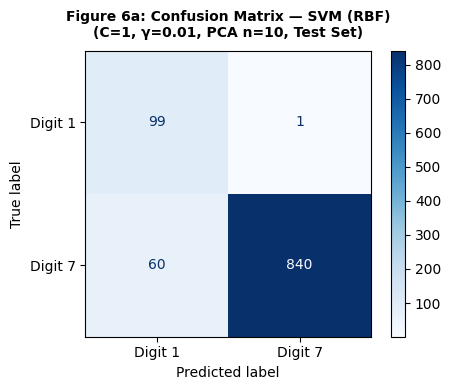

TN=99 | FP=1 | FN=60 | TP=840
Recall Digit 1: 0.9900 | Recall Digit 7: 0.9333


In [10]:
fig, ax = plt.subplots(figsize=(5, 4), facecolor='white')
cm_svm = confusion_matrix(y_test, svm_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm,
                               display_labels=['Digit 1', 'Digit 7'])
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Figure 6a: Confusion Matrix — SVM (RBF)\n'
             '(C=1, γ=0.01, PCA n=10, Test Set)',
             fontsize=10, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_svm.ravel()
print(f"TN={tn} | FP={fp} | FN={fn} | TP={tp}")
print(f"Recall Digit 1: {tn/(tn+fp):.4f} | Recall Digit 7: {tp/(tp+fn):.4f}")


### 4.3 Figure 6b: Confusion Matrix — Logistic Regression

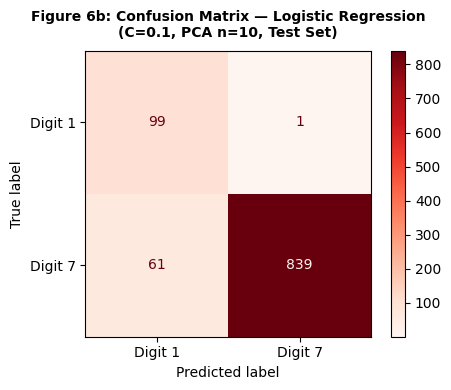

TN=99 | FP=1 | FN=61 | TP=839
Recall Digit 1: 0.9900 | Recall Digit 7: 0.9322


In [11]:
fig, ax = plt.subplots(figsize=(5, 4), facecolor='white')
cm_lr = confusion_matrix(y_test, lr_pred)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                                display_labels=['Digit 1', 'Digit 7'])
disp2.plot(ax=ax, colorbar=True, cmap='Reds')
ax.set_title('Figure 6b: Confusion Matrix — Logistic Regression\n'
             '(C=0.1, PCA n=10, Test Set)',
             fontsize=10, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_lr.ravel()
print(f"TN={tn} | FP={fp} | FN={fn} | TP={tp}")
print(f"Recall Digit 1: {tn/(tn+fp):.4f} | Recall Digit 7: {tp/(tp+fn):.4f}")


### 4.4 Classification Reports

In [12]:
for name, pred in [('SVM (RBF)', svm_pred), ('Logistic Regression', lr_pred)]:
    print(f"--- {name} ---")
    print(classification_report(y_test, pred, target_names=['Digit 1', 'Digit 7']))


--- SVM (RBF) ---
              precision    recall  f1-score   support

     Digit 1       0.62      0.99      0.76       100
     Digit 7       1.00      0.93      0.96       900

    accuracy                           0.94      1000
   macro avg       0.81      0.96      0.86      1000
weighted avg       0.96      0.94      0.94      1000

--- Logistic Regression ---
              precision    recall  f1-score   support

     Digit 1       0.62      0.99      0.76       100
     Digit 7       1.00      0.93      0.96       900

    accuracy                           0.94      1000
   macro avg       0.81      0.96      0.86      1000
weighted avg       0.96      0.94      0.94      1000



### 4.5 Figure 7: ROC Curves

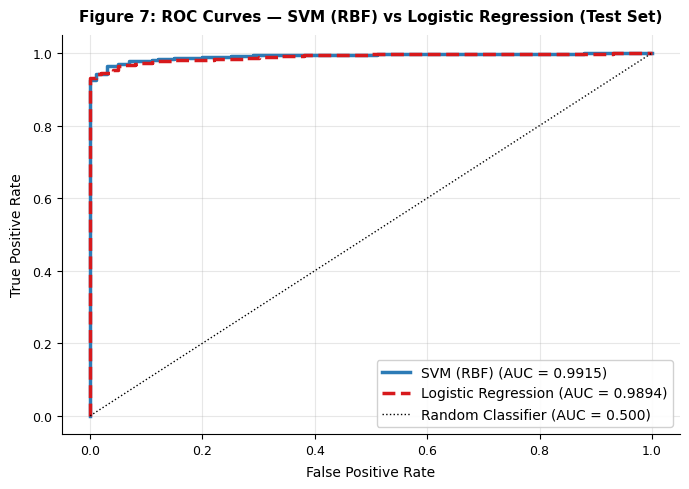

In [13]:
fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')

for name, prob, color, ls in [
    ('SVM (RBF)',           svm_prob, '#2C7BB6', '-'),
    ('Logistic Regression', lr_prob,  '#D7191C', '--')]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, linewidth=2.5, color=color,
            linestyle=ls, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0,1],[0,1], 'k:', linewidth=1, label='Random Classifier (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=10, labelpad=6)
ax.set_ylabel('True Positive Rate', fontsize=10, labelpad=6)
ax.set_title('Figure 7: ROC Curves — SVM (RBF) vs Logistic Regression (Test Set)',
             fontsize=11, fontweight='bold', pad=10)
ax.legend(fontsize=10, loc='lower right', framealpha=0.9)
ax.tick_params(labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Results Summary

In [14]:
print("=" * 55)
print("Final Comparison — Test Set Metrics")
print("=" * 55)
print(df_results.to_string())
print("=" * 55)
print()
for metric in ['Accuracy', 'F1-Score', 'AUC-ROC']:
    svm_val = svm_m[metric]
    lr_val  = lr_m[metric]
    winner  = 'SVM (RBF)' if svm_val >= lr_val else 'Logistic Regression'
    print(f"Best {metric}: {winner} ({max(svm_val, lr_val):.4f})")


Final Comparison — Test Set Metrics
                           SVM (RBF) Logistic Regression
Accuracy                       0.939               0.938
F1-Score                       0.965              0.9644
AUC-ROC                       0.9915              0.9894
Recall (Digit 1)                0.99                0.99
Recall (Digit 7)              0.9333              0.9322
TN / FP / FN / TP  99 / 1 / 60 / 840   99 / 1 / 61 / 839

Best Accuracy: SVM (RBF) (0.9390)
Best F1-Score: SVM (RBF) (0.9650)
Best AUC-ROC: SVM (RBF) (0.9915)


## 6. Save Models

In [15]:
joblib.dump(best_svm,  'svm_rbf_best.pkl')
joblib.dump(best_lr,   'lr_best.pkl')
joblib.dump(svm_grid,  'svm_gridsearch.pkl')
joblib.dump(lr_grid,   'lr_gridsearch.pkl')

print("Saved: svm_rbf_best.pkl")
print("Saved: lr_best.pkl")
print("Saved: svm_gridsearch.pkl")
print("Saved: lr_gridsearch.pkl")

# Verify reload
loaded_svm = joblib.load('svm_rbf_best.pkl')
loaded_lr  = joblib.load('lr_best.pkl')
print(f"\nVerification SVM Accuracy : {accuracy_score(y_test, loaded_svm.predict(X_test)):.4f}")
print(f"Verification LR  Accuracy : {accuracy_score(y_test, loaded_lr.predict(X_test)):.4f}")


Saved: svm_rbf_best.pkl
Saved: lr_best.pkl
Saved: svm_gridsearch.pkl
Saved: lr_gridsearch.pkl

Verification SVM Accuracy : 0.9390
Verification LR  Accuracy : 0.9380


## Appendix A: Full Hyperparameter Search Results

In [16]:
svm_full = svm_res[['param_pca__n_components','param_clf__C','param_clf__gamma',
                     'mean_test_score','std_test_score','rank_test_score']].copy()
svm_full.columns = ['n_components','C','gamma','Mean F1','Std F1','Rank']
svm_full['Mean F1'] = svm_full['Mean F1'].round(4)
svm_full['Std F1']  = svm_full['Std F1'].round(4)
svm_full = svm_full.sort_values('Rank').reset_index(drop=True)

print("Appendix A1: SVM Full Results (100 combinations)")
print(svm_full.to_string(index=False))


Appendix A1: SVM Full Results (100 combinations)
 n_components      C  gamma  Mean F1  Std F1  Rank
           10   1.00   0.01   1.0000  0.0000     1
           10  10.00   0.01   1.0000  0.0000     1
           50  10.00  0.001   1.0000  0.0000     1
           30  10.00  0.001   1.0000  0.0000     1
           20  10.00  0.001   1.0000  0.0000     1
           10 100.00  0.001   1.0000  0.0000     1
           10  10.00  0.001   1.0000  0.0000     1
           10 100.00   0.01   1.0000  0.0000     1
           50 100.00  0.001   1.0000  0.0000     1
           20  10.00   0.01   0.9905  0.0190    10
           50   1.00  scale   0.9905  0.0190    10
           20   1.00  scale   0.9905  0.0190    10
           10   1.00  scale   0.9905  0.0190    10
           30 100.00  scale   0.9905  0.0190    10
           50   1.00   0.01   0.9905  0.0190    10
           30   1.00   0.01   0.9905  0.0190    10
           20   1.00   0.01   0.9905  0.0190    10
           30   1.00  scale   0.9

In [17]:
lr_full = lr_res[['param_pca__n_components','param_clf__C',
                   'mean_test_score','std_test_score','rank_test_score']].copy()
lr_full.columns = ['n_components','C','Mean F1','Std F1','Rank']
lr_full['Mean F1'] = lr_full['Mean F1'].round(4)
lr_full['Std F1']  = lr_full['Std F1'].round(4)
lr_full = lr_full.sort_values('Rank').reset_index(drop=True)

print("Appendix A2: Logistic Regression Full Results (24 combinations)")
print(lr_full.to_string(index=False))


Appendix A2: Logistic Regression Full Results (24 combinations)
 n_components       C  Mean F1  Std F1  Rank
           50 100.000   1.0000  0.0000     1
           20 100.000   1.0000  0.0000     1
           10 100.000   1.0000  0.0000     1
           50  10.000   1.0000  0.0000     1
           30  10.000   1.0000  0.0000     1
           20  10.000   1.0000  0.0000     1
           10  10.000   1.0000  0.0000     1
           10   0.100   1.0000  0.0000     1
           30   1.000   1.0000  0.0000     1
           20   1.000   1.0000  0.0000     1
           30 100.000   1.0000  0.0000     1
           10   1.000   1.0000  0.0000     1
           50   1.000   0.9905  0.0190    13
           50   0.100   0.9905  0.0190    13
           20   0.100   0.9905  0.0190    13
           30   0.100   0.9905  0.0190    13
           50   0.010   0.9799  0.0246    17
           30   0.010   0.9799  0.0246    17
           20   0.010   0.9704  0.0242    19
           10   0.010   0.9704  0.02